# EDA For The DataSet

## Objectives

- Transform the InvoiceDate column to pandas datetime
- Perform statistical tests to check for hypothesis compatibility
- Look for correlations between the columns in the dataset
- Look for outliers and variance from hypothesis Zero for hypothesis with unique columns
- Use plots where possible to visualise the data and check for hypothesis compatibility
- Use Parametric and Non Parametric tests to test possible correlations between columns
- Create a special csv file machine learning containing:
  - TerritoryCodes
  - InvoiceAmt
  - YearMonth
  - Year
  Grouped by TerritoryCodes and YearMonth with InvoiceAmt as a sum
- Create a special csv file machine learning containing:
  - CustomerID
  - InvoiceAmt
  - YearMonth
  - Year
  Grouped by CustomerID and YearMonth with InvoiceAmt as a sum


## Inputs

CSV file used:

Sales_InvoiceData_Visualization.csv


## Outputs

Plots for testing validity of each hypothesis before considering visualisation


## Additional Comments

Developed an experimental ETL library which is in this project (modETL_library.py) 
Has lots of cool features so will be interesting to see how it works "in the field"



In [1]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import kruskal
#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from scipy.stats import spearmanr

#added by me for plotly.express visualisation issue
import nbformat 

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 


In [2]:
#DataFrame variables for EDA
dfSales_DataSet_Work = None
dfSales_DataSet_Temp = None
dfSales_DataSet_Temp1 = None
dfSales_DataSet_Temp2 = None
dfSales_DataSet_Sample1 = None
dfSales_DataSet_Sample2 = None
dfSales_DataSet_Sample3 = None
dfSales_DataSet_GroupedByTerritory = None
dfSales_DataSet_GroupedByCustomer = None

#stores current directory
strCurrentDir = ""

#other vars
dictDataFrames = dict()
fig = None
axis = None
fltShapiroStat = 0.0
fltShapiroP = 0.0
fltMannWhitneyU = 0.0
fltMannWhitneyUStat = 0.0
fltMannWhitneyUp = 0.0
fltTStatistic = 0.0 
fltPValue = 0.0
fltStat = 0.0
fltRHO = 0.0
fltR = 0.0
intStart = 0
intEnd = 0
intYear = 0
objGroups = None



## Set Current Directory To Base Project Directory


In [3]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis


# Section 2

- Read csv file
- Convert Date column to datetime
- Look at skew, kurtosis and Q-Q plots for ALL numeric columns

Why all numeric columns?

Just being thorough and want to see if there are any other columns that may be useful for analysis



In [4]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
          
dfSales_DataSet_Work = dictDataFrames["Sales_InvoiceData_Visualisation.csv"]
                                  

2 csv Files Read Into DataFrames

DataFrames Created:
Sales_InvoiceData_GroupedByTerritory_Visualisation.csv
Sales_InvoiceData_Visualisation.csv




/Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis/assets/python_files/modETL_Library.py:452: DtypeWarning: Columns (0: InvoiceID) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTemp = pd.read_csv(os.getcwd() + modGlobal.CNST_STR_DATA_VISUALISATIONPATH + "/" + strFile)


# Transform The Date Column To Pandas Datetime

In [5]:
#convert Date column to pandas datetime
dfSales_DataSet_Work["InvoiceDate"] = pd.to_datetime(dfSales_DataSet_Work["InvoiceDate"], format="%d/%m/%Y") 

# Get Column Skew/Kurtosis

DataFrame Skew Values Per Column:
Unnamed: 0           Skew: 0.00 - Approximately Symmetrical Kurtosis: -1.20
InvoiceDate          Skew: 0.16 - Approximately Symmetrical Kurtosis: -1.20
InvoiceQty           Skew: 27.17 - Highly Positively Skewed Kurtosis: 1252.70
InvoiceAmt           Skew: 24.63 - Highly Positively Skewed Kurtosis: 1040.43
Day                  Skew: -0.03 - Highly Negatively Skewed Kurtosis: -1.16
Month                Skew: -0.01 - Highly Negatively Skewed Kurtosis: -1.17
Year                 Skew: 0.14 - Approximately Symmetrical Kurtosis: -1.24
Quarter              Skew: 0.00 - Approximately Symmetrical Kurtosis: -1.32
YearMonth            Skew: 1.23 - Highly Positively Skewed Kurtosis: -0.48

Q-Q Plot For Column: Unnamed: 0


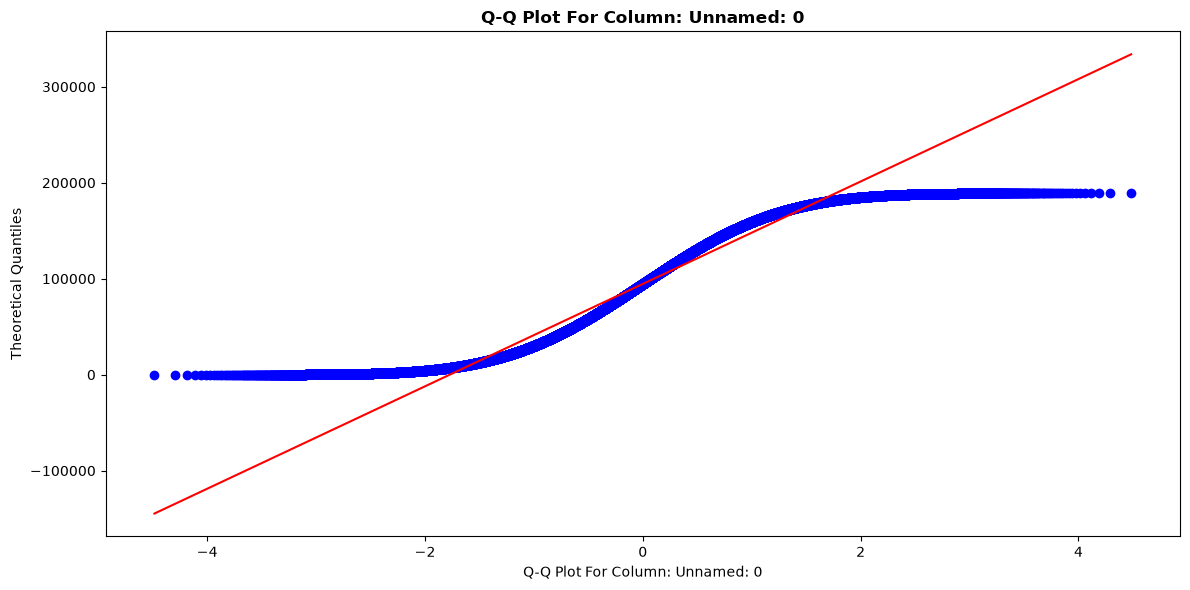



Q-Q Plot For Column: InvoiceDate


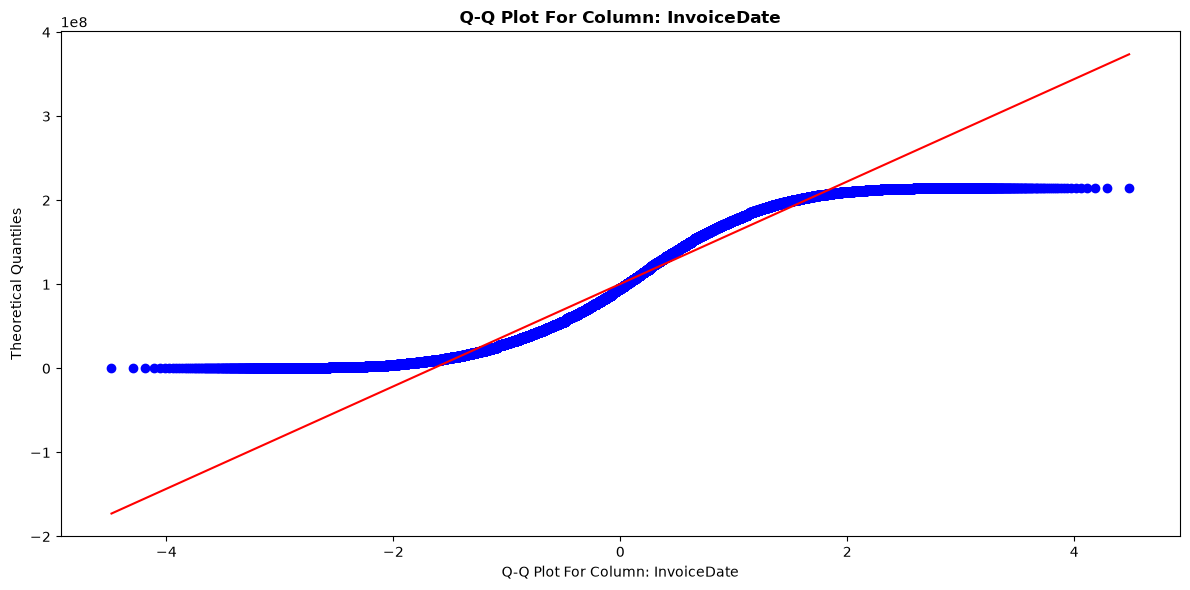



Q-Q Plot For Column: InvoiceQty


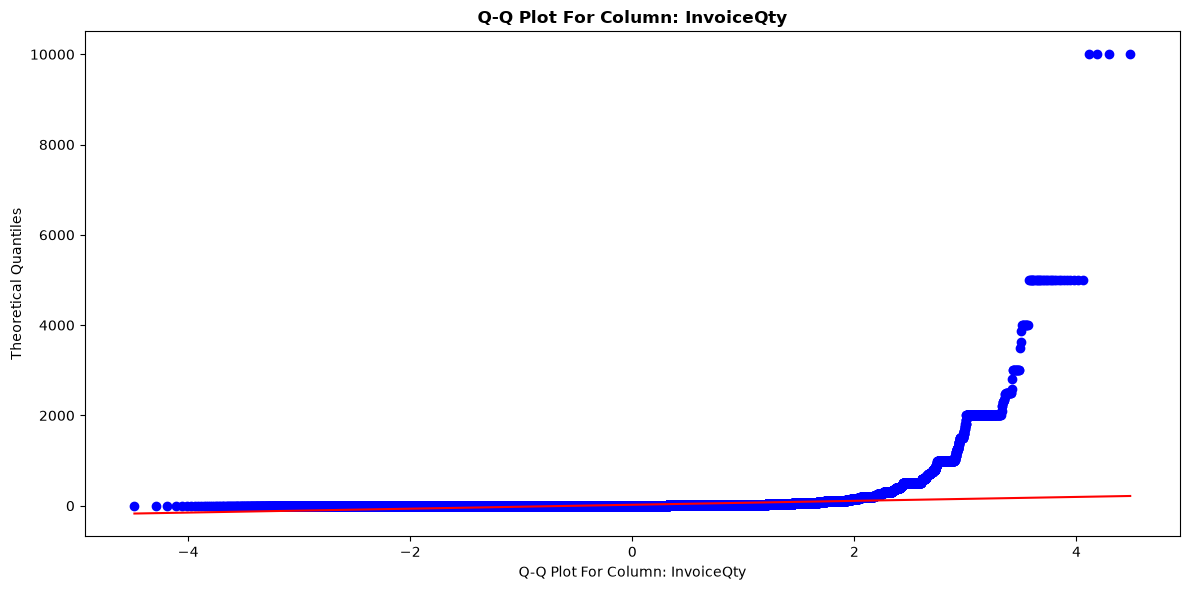



Q-Q Plot For Column: InvoiceAmt


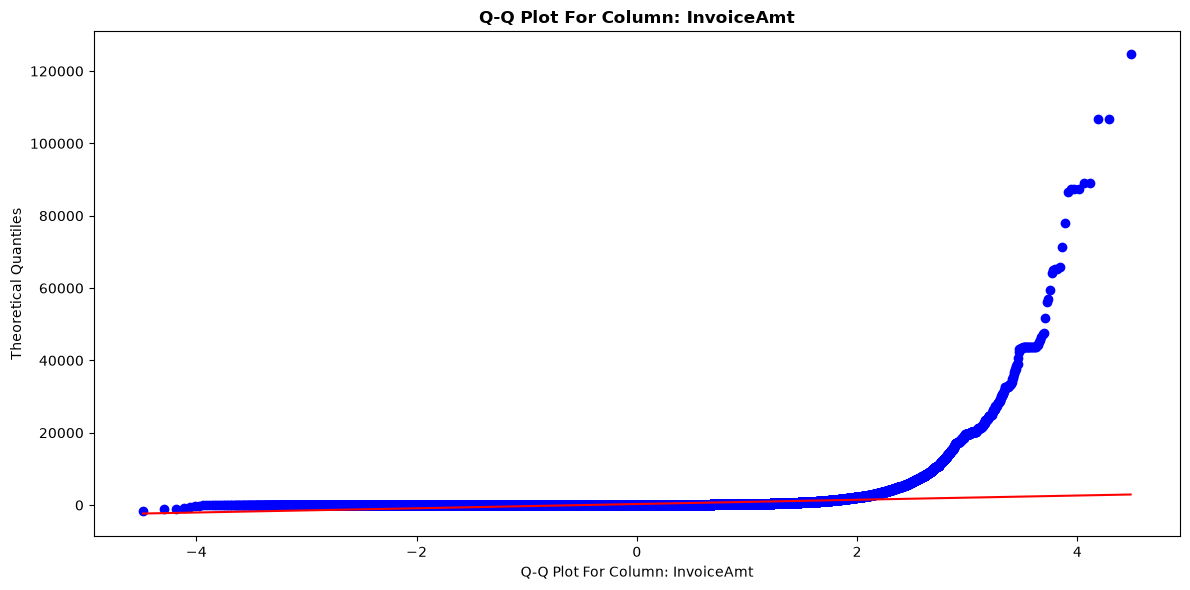



Q-Q Plot For Column: Day


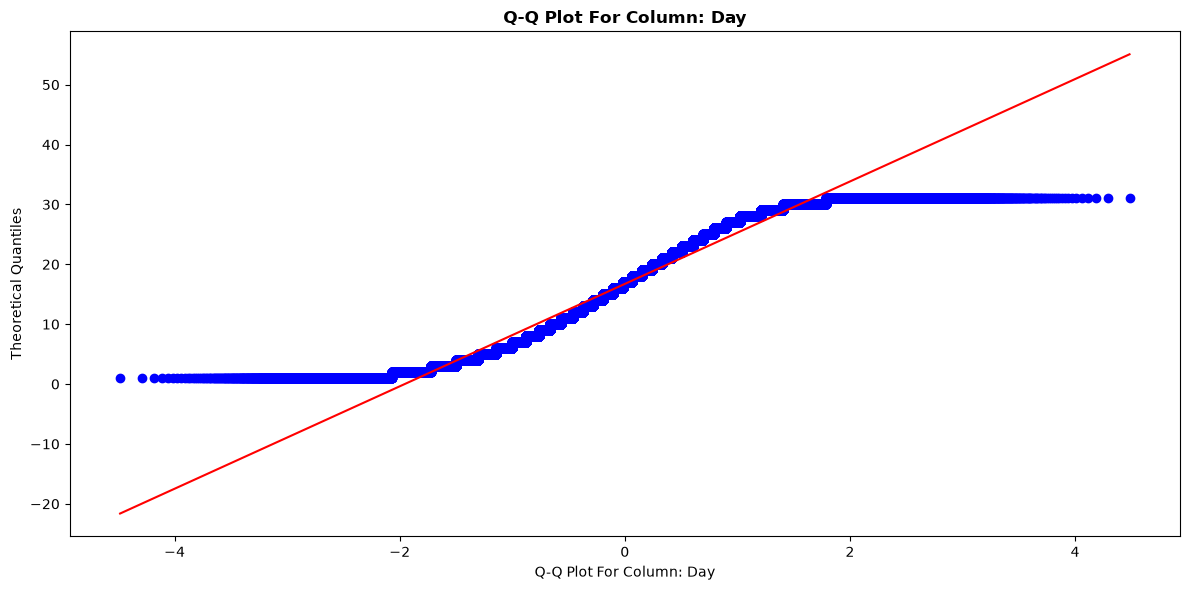



Q-Q Plot For Column: Month


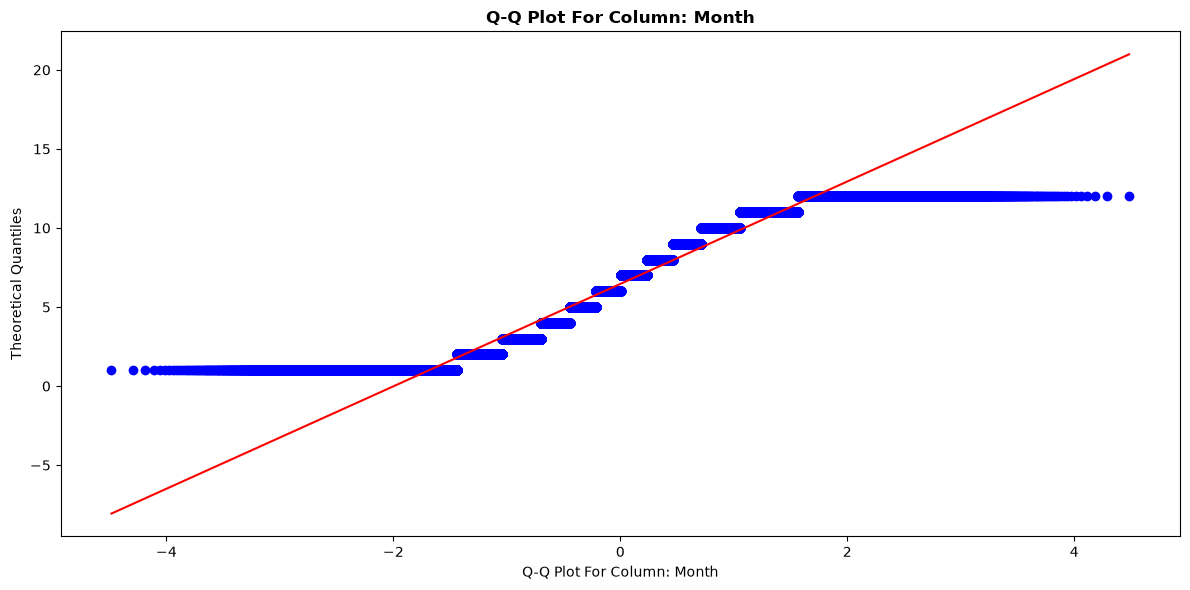



Q-Q Plot For Column: Year


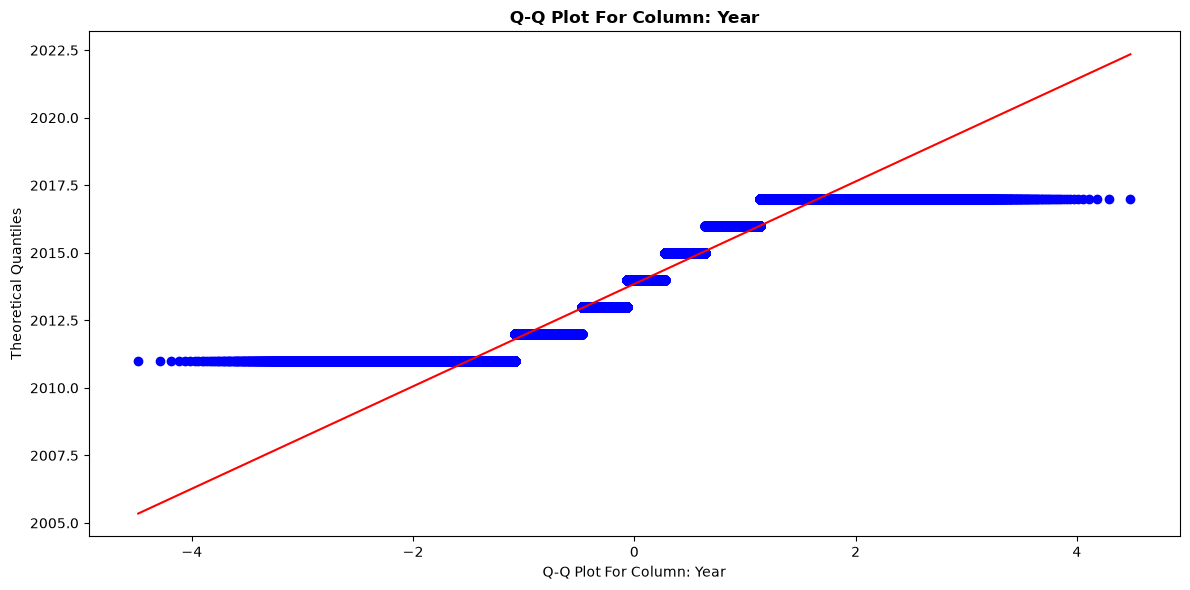



Q-Q Plot For Column: Quarter


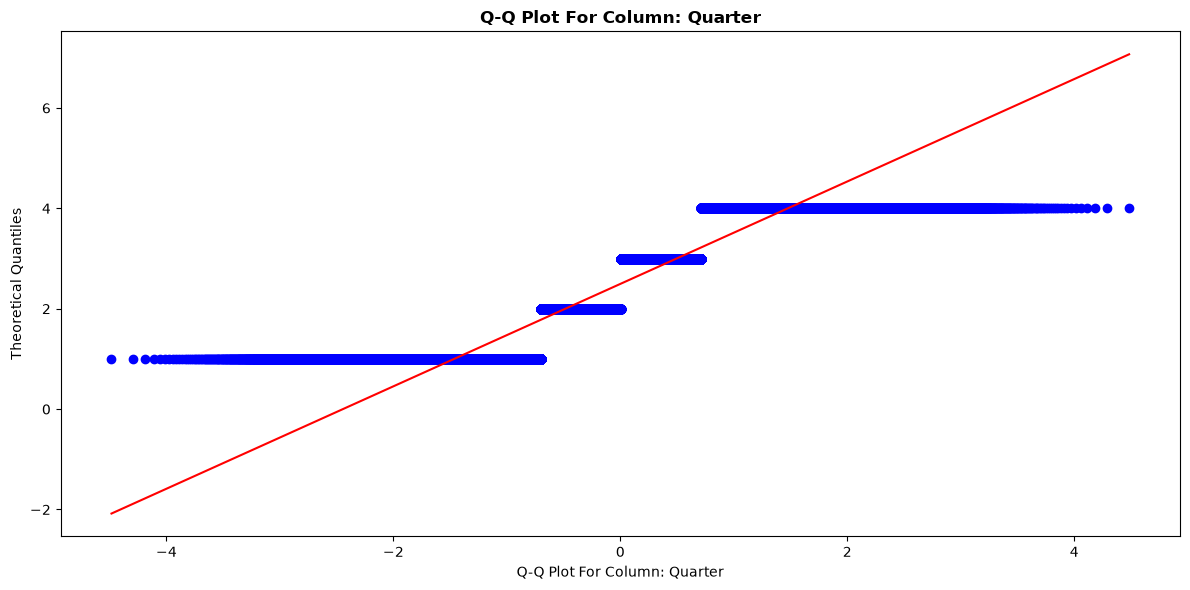



Q-Q Plot For Column: YearMonth


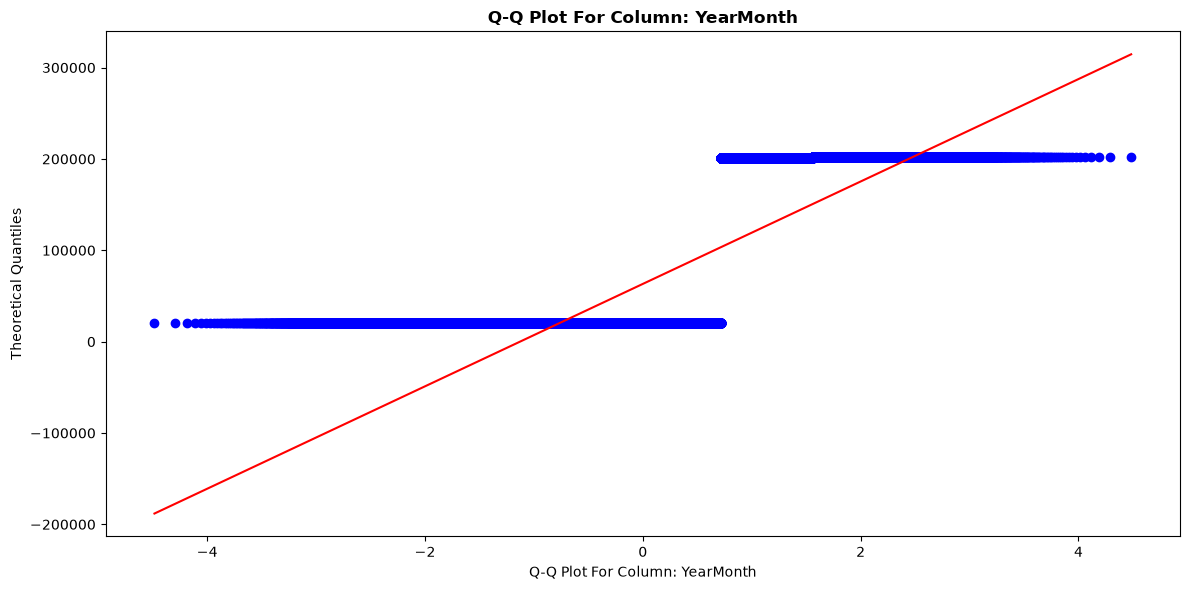

In [6]:
#get column skew/kurtosis and show some Q-Q plots where possible

modETL.funcGetColumnSkew(dfSales_DataSet_Work)

# Observations: EDA - Sales DataSet

Due to the nature of the columns not much value can be gained from skew and kurtosis. It is obvious it is in correlations where real meaning can be obtained

The bar chart shows Invoice qty/amount columns as being most skewed which is not surprsing so typically need to correlated in order for the values to have meaning


## InvoiceID Is A String - Why?

Do test to show if really needs to be a string

In [7]:
#test to see if InvoiceID can be a number

dfSales_DataSet_Work = dfSales_DataSet_Work.copy()

# #crude test - direct conversion to string
try:
   dfSales_DataSet_Work["InvoiceID"] = dfSales_DataSet_Work["InvoiceID"].astype("string")
except Exception as e:
   print(f"InvoiceID cannot be converted to string error: {e}")

dfSales_DataSet_Temp1 = dfSales_DataSet_Work.sort_values(by=["InvoiceID"],ascending=False)  
dfSales_DataSet_Temp1.head(100)  



,Unnamed: 0,InvoiceID,InvoiceDate,ItemID,ItemName,ProductFamily,InvoiceQty,InvoiceAmt,CustomerID,CustomerName,TerritoryCodes,ContactName,ShipMethod,Day,Month,Year,Quarter,YearMonth
163352,163352,CM260609,2016-11-29,FP-MISC,Miscellaneous,Lumino,1.0,-53.34,589,J Smith,South East/London,NaN,UK Carrier,29,11,2016,4,201611
161070,161070,CM259611,2016-10-25,FP-MISC,Miscellaneous,Fire Product,1.0,-808.34,526,Cesar Debbas & Fils,South East/London,Fadia Sakr,Export,25,10,2016,4,201610
133716,133716,CM247313,2015-09-24,DY/LED/M3/CR/3K ORB,"Dyode LED M3 Ceiling Mounted D/lighter, Corrid...",Dyode,1.0,-353.52,30,D C,South East/London,Sandi Jenkinson,Despatch Next Day,24,9,2015,3,20159
132680,132680,CM246797,2015-09-09,na/led/m3 orb,Napoli 6500K LED M3 S/Sided E/Sign,Napoli,1.0,-36.76,255,4D Lighting Limited,South East/London,NaN,UK Carrier,9,9,2015,3,20159
132605,132605,CM246743,2015-09-08,LAR/LED/CH/4K ORB,Larino Mains LED Chrome finish Inc 4000K LEDs ...,Larino,1.0,-66.11,534,GLAMOX LUXONIC LIMITED,South East/London,NaN,Export,8,9,2015,3,20159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189066,189066,272055,2017-12-21,NA8/M3/E ORB,8W M3 Napoli S/Sided E/Sign Economy Version In...,Napoli,139.0,4385.45,59,Al Khalili United Enterprises,Non EU,Mr. Adnan,Export,21,12,2017,4,201712
189067,189067,272055,2017-12-21,L19EB,Legend L19 For E/B 379 X 186 X 2mm Opal Poly...,Accessories,119.0,0.00,59,Al Khalili United Enterprises,Non EU,Mr. Adnan,Export,21,12,2017,4,201712
189088,189088,272055,2017-12-21,SAV8/M3/WH/A ORB,8W HF M3 Savona Edge Lit E/Sign Head White Si...,Savona,37.0,2012.80,59,Al Khalili United Enterprises,Non EU,Mr. Adnan,Export,21,12,2017,4,201712
189089,189089,272055,2017-12-21,L22EB,Legend L22 (Arabic Makhrage) for S/Sided E/Bo...,Accessories,20.0,0.00,59,Al Khalili United Enterprises,Non EU,Mr. Adnan,Export,21,12,2017,4,201712


## Observations: InvoiceID Is A String - Why?

Results show why, there are InvoiceIDs which contain text, clearly these are credit memos
Will note this finding for later when visualising the hypothesis as might need to split data between credits and
non credits

# Section 3 - More Analysis

Here we perform these tests where possible:

- Missing values heatmap
- Q-Q Plots
- Shapiro-Wilk Test
- Parametric Tests
- Non-Parametric Tests


# Missing Values Heatmap

Double check what we did in the ETL notebook and use a heatmap to show any missing values
Am expecting just the CUS_ContactName column to appear in the plot with values, luckily thiis column
is not required for visualisation so will ignore it

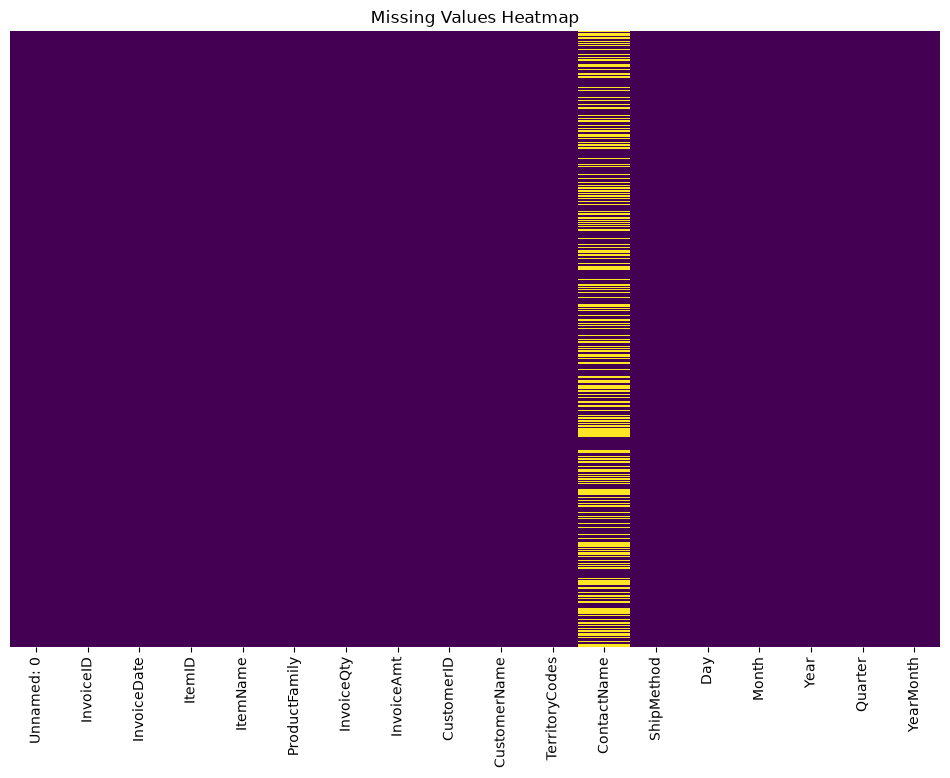

In [8]:
#create missing values heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    dfSales_DataSet_Work .isna(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

#set title and show plot
plt.title("Missing Values Heatmap")
plt.show()



## Observations - Missing Values Heatmap

As expected the only column with missing values is CUS_ContactName which is not required for visualisation so will ignore it 

## How Many? - Values

See how many values in key columns

In [9]:
#get how many? values for useful columns

print("How Many? - Values For Key Columns")
print("=" * len("How Many? - Values For Key Columns"))
print(f"Rows: {len(dfSales_DataSet_Work)}")
print(f"Invoices: {dfSales_DataSet_Work['InvoiceID'].nunique()}")
print(f"Customers: {dfSales_DataSet_Work['CustomerID'].nunique()}")
print(f"Items: {dfSales_DataSet_Work['ItemID'].nunique()}")
print(f"Product Families: {dfSales_DataSet_Work['ProductFamily'].nunique()}")
print(f"Territories: {dfSales_DataSet_Work['TerritoryCodes'].nunique()}")
print(f"Ship Methods: {dfSales_DataSet_Work['ShipMethod'].nunique()}")
print()

How Many? - Values For Key Columns
Rows: 189151
Invoices: 78001
Customers: 1928
Items: 7558
Product Families: 130
Territories: 34
Ship Methods: 12



## Observations: How Many? - Values

Not seeing any wayward values, nice consistency in the dataset, which is good for visualisation and analysis

## How Many? - Numeric Values

Now check:

- InvoiceAmt <- looking for mean/median/sum and negative amounts (credits)
- InvoiceQty

In [10]:
#get how many? values for useful columns
print("How Many? - Values")
print("=" * len("How Many? - Values"))
print(f"Rows: {len(dfSales_DataSet_Work)}")
print(f"Invoice Amount Sum: {dfSales_DataSet_Work['InvoiceAmt'].sum()}")
print(f"Invoice Amount Mean: {dfSales_DataSet_Work['InvoiceAmt'].mean()}")
print(f"Invoice Amount Median: {dfSales_DataSet_Work['InvoiceAmt'].median()}")
print(f"Invoice Amount Negative: {(dfSales_DataSet_Work['InvoiceAmt'] < 0).sum()}")
print(f"Invoice Qty Sum: {dfSales_DataSet_Work['InvoiceQty'].nunique()}")
print()

#show negative invoiceamt records
dfSales_DataSet_Work[dfSales_DataSet_Work["InvoiceAmt"] < 0].sort_values("InvoiceAmt").head(20)


How Many? - Values
Rows: 189151
Invoice Amount Sum: 56154043.3
Invoice Amount Mean: 296.8741550401531
Invoice Amount Median: 47.32
Invoice Amount Negative: 10
Invoice Qty Sum: 592



,Unnamed: 0,InvoiceID,InvoiceDate,ItemID,ItemName,ProductFamily,InvoiceQty,InvoiceAmt,CustomerID,CustomerName,TerritoryCodes,ContactName,ShipMethod,Day,Month,Year,Quarter,YearMonth
103780,103780,CM233343,2014-07-10,FP-MISC,Miscellaneous,Commissioning,1.0,-1723.44,S1792,Grant & Stone Limited,South East/London,NaN,UK Carrier,10,7,2014,3,20147
8621,8621,CM185641,2011-06-10,KAL214/M3/A/SG ORB,Kalix 2x14W T5 M3 Style A. Silver Grey,Kalix,1.0,-1100.88,IR13,Wesco Electrical Limited,South East/London,NaN,Export,10,6,2011,2,20116
131705,131705,CM246356,2015-08-24,AR2X8/110D ORB,110V AC/DC 2x8W Arc Clear Diffuser,Arc,1.0,-947.71,1028,Imci Services Ltd,South East/London,do not change above email,Export,24,8,2015,3,20158
161070,161070,CM259611,2016-10-25,FP-MISC,Miscellaneous,Fire Product,1.0,-808.34,526,Cesar Debbas & Fils,South East/London,Fadia Sakr,Export,25,10,2016,4,201610
129765,129765,CM245429,2015-07-27,PIC8/NM3/E ORB,8W NM3 S/Sided Pico E/Box White Economy Version,Pico,1.0,-526.93,1607,Zubair Electric LLC,South East/London,MR GURURAJ HEGDE,Export,27,7,2015,3,20157
133716,133716,CM247313,2015-09-24,DY/LED/M3/CR/3K ORB,"Dyode LED M3 Ceiling Mounted D/lighter, Corrid...",Dyode,1.0,-353.52,30,D C,South East/London,Sandi Jenkinson,Despatch Next Day,24,9,2015,3,20159
11607,11607,CM187234,2011-07-12,PLR5418P3 ORB,M3 LowProfile Module+DDP 4x4Ah For Use With 18...,PLR-Range,1.0,-195.30,1079,EUROLIGHTING LTD T-A E2 CONTRACT LIGHTING,South East/London,Mark Adams/Jan Scrivens,UK Carrier,12,7,2011,3,20117
132605,132605,CM246743,2015-09-08,LAR/LED/CH/4K ORB,Larino Mains LED Chrome finish Inc 4000K LEDs ...,Larino,1.0,-66.11,534,GLAMOX LUXONIC LIMITED,South East/London,NaN,Export,8,9,2015,3,20159
163352,163352,CM260609,2016-11-29,FP-MISC,Miscellaneous,Lumino,1.0,-53.34,589,J Smith,South East/London,NaN,UK Carrier,29,11,2016,4,201611
132680,132680,CM246797,2015-09-09,na/led/m3 orb,Napoli 6500K LED M3 S/Sided E/Sign,Napoli,1.0,-36.76,255,4D Lighting Limited,South East/London,NaN,UK Carrier,9,9,2015,3,20159


## Observations: How Many? - Numeric Values

There are only 10 negative values in the InvoiceAmt column which is good for the customer!


## Distribution Of Invoice Amounts

Show a plots of the distribution of invoice amounts for last year in dataset

Q-Q Plot For Invoice Amount For 2017


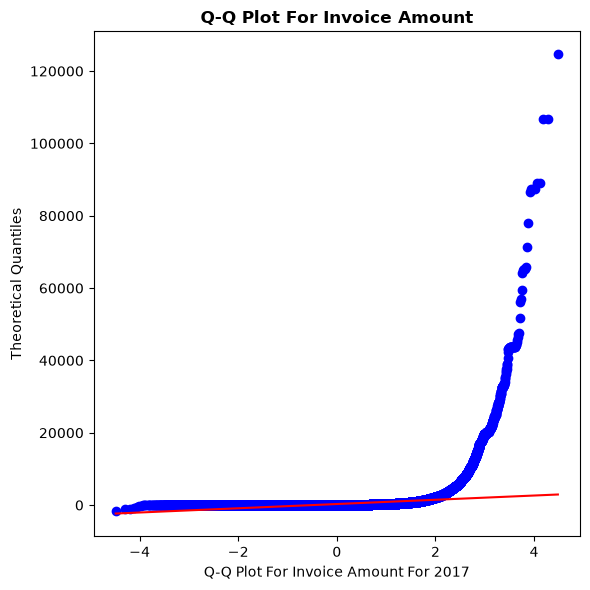

BoxPlot For Invoice Amount For 2017


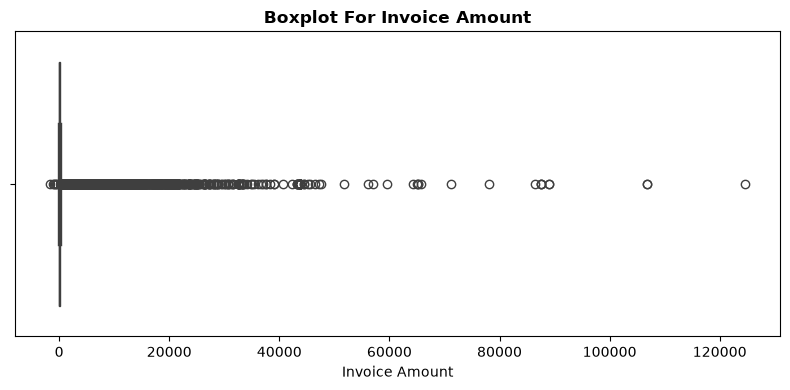


Shapiro-Wilk p-value Test Results For InvoiceAmt Column For 2016 and 2017
Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: 0.0000



In [11]:
#show distribution of invoice amounts

intYear = dfSales_DataSet_Work['InvoiceDate'].dt.year.max()

fig = px.histogram(
    dfSales_DataSet_Work,
    x="InvoiceAmt",
    nbins=50,
    title=f"Distribution of Invoice Amount for {intYear}",
    labels={"InvoiceAmt": "Invoice Amount"}
)

#add axis titles
fig.update_layout(
    xaxis_title="Invoice Amount",
    yaxis_title="Frequency",
    bargap=0.1,
    height=800,
    width=1100
)

fig.show()
#show Q-Q plot for InvoiceAmt column
    
#filter data for one year
dfSales_DataSet_Temp = dfSales_DataSet_Work[dfSales_DataSet_Work["InvoiceDate"].dt.year == 
                                            dfSales_DataSet_Work["InvoiceDate"].dt.year.max()]
    
#configure plot
fig, axis = plt.subplots(figsize=(6, 6))

#print Q-Q plot for weekly sales
print(f"Q-Q Plot For Invoice Amount For {intYear}")
print("=" * len(f"Q-Q Plot For Invoice Amount For {intYear}"))
#configure plot
stats.probplot(dfSales_DataSet_Work["InvoiceAmt"], dist="norm", plot=plt)
plt.title("Q-Q Plot For Invoice Amount", fontweight="bold")
axis.set_xlabel(f"Q-Q Plot For Invoice Amount For {intYear}")
axis.set_ylabel("Theoretical Quantiles")
plt.tight_layout()
plt.show()

# #now repeat using boxplot
print(f"BoxPlot For Invoice Amount For {intYear}")
print("=" * len(f"BoxPlot For Invoice Amount For {intYear}"))
#configure plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=dfSales_DataSet_Work["InvoiceAmt"])
plt.title("Boxplot For Invoice Amount", fontweight="bold")
plt.xlabel("Invoice Amount")
plt.tight_layout()
plt.show()
print()

#Shapiro-Wilk Test
dfSales_DataSet_Sample3 = dfSales_DataSet_Work["InvoiceAmt"].sample(3000, random_state=42)
fltShapiroStat, fltShapiroP = stats.shapiro(dfSales_DataSet_Sample3)
print(f"Shapiro-Wilk p-value Test Results For InvoiceAmt Column For {intYear - 1} and {intYear}")
print("=" * len(f"Shapiro-Wilk p-value Test Results For InvoiceAmt Column For {intYear - 1} and {intYear}"))
print(f"Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: {fltShapiroP:.4f}")
print()



## Observations: Distribution Of Invoice Amounts

Small amount of outliers, which is good as means data is not inherently skewed or even worse corrupt!
Nice to see the vast majority of the data is clustered in to 0 to 38000 range, which shows a certain
consistency in the dataset

Also the Q-Q plot show a huge swing away from alpha strongly suggesting a perpetual increase in sales

The Shapiro-Wilk p-value of 0 tells us the data is not normally distributed which is great as that means
hypothesis using InvoiceAmt is viable

## Check For Negative InvoiceQtys

Make sure the customer did not magically manage to sell products with a quantity less than one
That would get accounts attention! 

In [12]:
dfSales_DataSet_Work[dfSales_DataSet_Work["InvoiceQty"] <= 0]


,Unnamed: 0,InvoiceID,InvoiceDate,ItemID,ItemName,ProductFamily,InvoiceQty,InvoiceAmt,CustomerID,CustomerName,TerritoryCodes,ContactName,ShipMethod,Day,Month,Year,Quarter,YearMonth


## Observations: Check For Negative InvoiceQtys

Thankfully no values less than zero, if there were would have to consider whether to move those records out of the
live dataset into a new one for preservation and delete from the "live" datatset, or leave in......

Personally would move them out of the data and show the data to the customer and ask under what business conditions
this could occur

## Parametric/Non Parametric Tests For InvoiceAmt Column

In [13]:
#Non Parametric test for InvoiceAmt column
dfSales_DataSet_Temp = dfSales_DataSet_Work.copy()
intYear = dfSales_DataSet_Temp['InvoiceDate'].dt.year.max()
#get two samples for last two years
dfSales_DataSet_Temp1 = dfSales_DataSet_Temp[dfSales_DataSet_Temp["InvoiceDate"].dt.year == intYear -1]["InvoiceAmt"]
dfSales_DataSet_Temp2 = dfSales_DataSet_Temp[dfSales_DataSet_Temp["InvoiceDate"].dt.year == intYear]["InvoiceAmt"]
#get a nice big sample size
dfSales_DataSet_Sample1 = dfSales_DataSet_Temp1.sample(3000, random_state=42)
dfSales_DataSet_Sample2 = dfSales_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_DataSet_Temp1, dfSales_DataSet_Temp2)
print(f"Mann-Whitney Test Results For InvoiceAmt column For {intYear - 1} and {intYear}")
print("=" * len(f"Non Parametric Test Results For InvoiceAmt column For {intYear - 1} and {intYear}"))
print(f"statistic: {fltMannWhitneyUStat}")
print(f"p-value: {fltMannWhitneyUp:.4f}")
print()

#Parametric Individual T-Test for Weekly_Sales column for last two years set equal_var to false 
#as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_DataSet_Temp1, dfSales_DataSet_Temp2, equal_var = False, 
                                          nan_policy = "omit")
#print results
print(f"Independent Parametric T-Test Results For InvoiceAmt column For {intYear - 1} and {intYear}")
print("=" * len(f"Independent Parametric T-Test Results For InvoiceAmt column For {intYear - 1} and {intYear}"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_DataSet_Sample1, dfSales_DataSet_Sample2, equal_var = False, 
                                           nan_policy = "omit", alternative = "greater")
#print results
print(f"Independent Parametric T-Test Results For InvoiceAmt Column For Sample Data")
print("=" * len(f"Independent Parametric T-Test Results For InvoiceAmt Column For Sample Data"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#print mean sales
print(f"Invoice Amount For Sample 1 Mean Sales ({intYear -1}): £{dfSales_DataSet_Sample1.mean():,.2f}")
print(f"Invoice Amount For Sample 2 Mean Sales ({intYear}): £{dfSales_DataSet_Sample2.mean():,.2f}")


Mann-Whitney Test Results For InvoiceAmt column For 2016 and 2017
statistic: 305205386.5
p-value: 0.1317

Independent Parametric T-Test Results For InvoiceAmt column For 2016 and 2017
t-statistic: 0.6378
p-value: 0.5236

Independent Parametric T-Test Results For InvoiceAmt Column For Sample Data
t-statistic: -0.6825
p-value: 0.7525

Invoice Amount For Sample 1 Mean Sales (2016): £307.32
Invoice Amount For Sample 2 Mean Sales (2017): £340.97


## Observations: Parametric/Non Parametric Tests For InvoiceAmt Column

The Mann-Whitney U Test:
- Statistic value implies a smaller separation between the two values
- p-value being 0.1317 says it is well above alpha (0.05) which validates the Hypothesis Zero

Independent Parametric T-Test:
- t-statistic value implies a smaller separation between the two values 
- p-value being 0.5236 says it is above alpha (0.05) which validates the Hypothesis Zero (just)

Independent Parametric T-Test For 2016/2017:
- t-statistic value tells us that in the analysis the first groups mean was lower than the second
- p-value being 0.7525 says it is above alpha (0.05) which validates the Hypothesis Zero 


## Distribution of Invoice Quantities

See how the data looks, not exactly essential, but why not do it anyway for science!

Q-Q Plot For Invoice Quantity For 2017


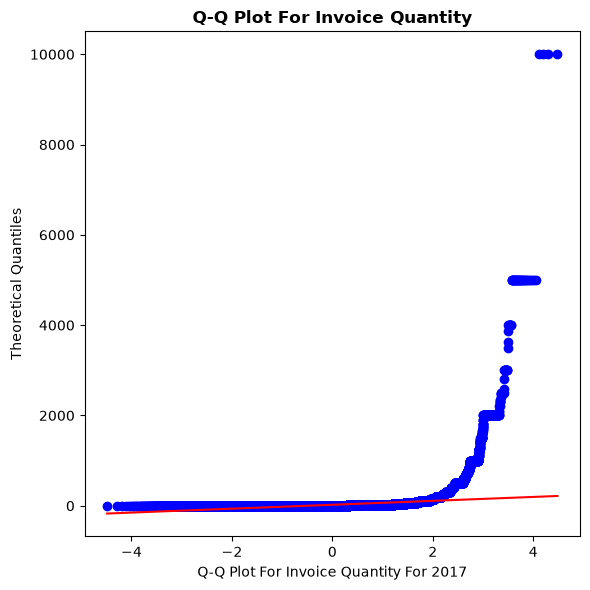

BoxPlot For Invoice Quantity For 2017


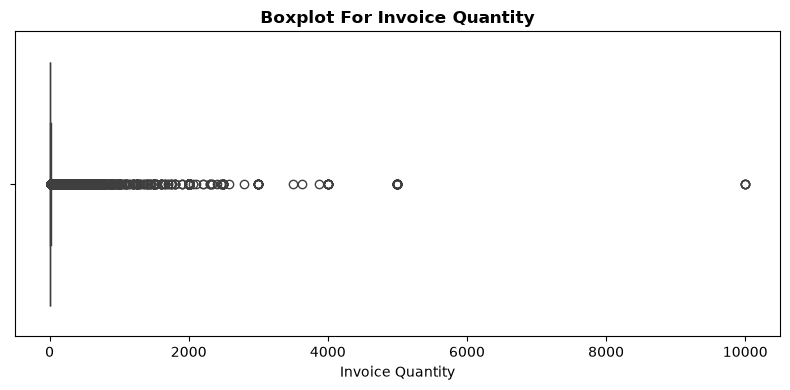


Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: 0.0000


In [14]:
#show distribution of invoice quantites
fig = px.histogram(
    dfSales_DataSet_Work,
    x="InvoiceQty",
    nbins=50,
    title=f"Distribution of Invoice Quantity for {dfSales_DataSet_Work['InvoiceDate'].dt.year.max()}",
    labels={"InvoiceQty": "Invoice Quantity"}
)

#add axis titles
fig.update_layout(
    xaxis_title="Invoice Quantity",
    yaxis_title="Frequency",
    bargap=0.1,
    height=800,
    width=1100
)

fig.show()
#show Q-Q plot for InvoiceAmt column
    
#filter data for one year
dfSales_DataSet_Temp = dfSales_DataSet_Work[dfSales_DataSet_Work["InvoiceDate"].dt.year == 
                                            dfSales_DataSet_Work["InvoiceDate"].dt.year.max()]
    
#configure plot
fig, axis = plt.subplots(figsize=(6, 6))

#print Q-Q plot for weekly sales
print(f"Q-Q Plot For Invoice Quantity For {dfSales_DataSet_Work["InvoiceDate"].dt.year.max()}")
print("=" * len(f"Q-Q Plot For Invoice Quantity For {dfSales_DataSet_Work["InvoiceDate"].dt.year.max()}"))
#configure plot
stats.probplot(dfSales_DataSet_Work["InvoiceQty"], dist="norm", plot=plt)
plt.title("Q-Q Plot For Invoice Quantity", fontweight="bold")
axis.set_xlabel(f"Q-Q Plot For Invoice Quantity For {dfSales_DataSet_Work['InvoiceDate'].dt.year.max()}")
axis.set_ylabel("Theoretical Quantiles")
plt.tight_layout()
plt.show()

# #now repeat using boxplot
print(f"BoxPlot For Invoice Quantity For {dfSales_DataSet_Work['InvoiceDate'].dt.year.max()}")
print("=" * len(f"BoxPlot For Invoice Quantity For {dfSales_DataSet_Work['InvoiceDate'].dt.year.max()}"))
#configure plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=dfSales_DataSet_Work["InvoiceQty"])
plt.title("Boxplot For Invoice Quantity", fontweight="bold")
plt.xlabel("Invoice Quantity")
plt.tight_layout()
plt.show()

print()
#Shapiro-Wilk Test for InvoiceQty column using 3000 sample size due to data size
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work["InvoiceQty"].sample(3000, random_state=42)
fltShapiroStat, fltShapiroP = stats.shapiro(dfSales_Combined_DataSet_Temp)
print(f"Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: {fltShapiroP:.4f}")



## Observations: Distribution of Invoice Quantities

Small amount of outliers, which is good as means data is not inherently skewed or even worse corrupt!
Nice to see the vast majority of the data is clustered in to 0 to 2500 range, which shows a certain
consistency in the dataset

Also the Q-Q plot show a huge swing away from alpha strongly suggesting a perpetual increase in sales
even though there is a break before its peak

The Shapiro-Wilk p-value of 0 tells us the data is not normally distributed which is great as that means
hypothesis using InvoiceQty is viable

## Is There A Significant Difference In InvoiceAmt Between TerritoryCodes?

Hypothetical test, to check data has no anomalies in it, should be a correlation!

In [15]:
#show a plot comparing territorycodes and their invoice amounts for last year in dataset
dfSales_DataSet_Temp = dfSales_DataSet_Work.copy()

#filter by last year of data
dfSales_DataSet_Temp = dfSales_DataSet_Temp[dfSales_DataSet_Temp["Year"] == dfSales_DataSet_Temp["Year"].max()]

#use a bar plot as it looks cleaner
fig = px.bar(
    dfSales_DataSet_Temp,
    x="TerritoryCodes",
    y="InvoiceAmt",
    barmode="group",
    title=f"Invoice Amount By Territory For {dfSales_DataSet_Temp["Year"].max()}",
    labels={"InvoiceAmt": "Invoice Amount", "TerritoryCodes": "Territory Codes"}
)
#configure plot
fig.update_layout(
    xaxis_title="Territory Codes",
    yaxis_title="Invoice Amount",
    legend_title="Product Family",
    font=dict(size=12),
    title_font=dict(size=16),
    title_x=0.5,
    title_y=0.9,
    margin=dict(l=50, r=50, t=120, b=50),
    height=900,
    width=1000
)

fig.show()




## Observations: Is There A Significant Difference In InvoiceAmt Between TerritoryCodes?

Yes! Nice to see the data is consistent and has a decent spread, pity I could not "zoom" in to show all them
small values

# Parametric/Non Parametric Tests

Run tests on these column combinations:
- TerritoryCode and InvoiceAmt
- InvoiceQty and InvoiceAmt
- ItemID and InvoiceAmt

# TerritoryCodes and InvoiceAmt

In [16]:
#run Kruskal-Wallis test to see if there is a significant difference between the means of the groups

#copied from chatGPT and edited as necessary
objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("TerritoryCodes")
]

fltStat, fltPValue = kruskal(*objGroups)

print(f"Kruskal-Wallis Test Results For InvoiceAmt Column By TerritoryCodes")
print("=" * len(f"Kruskal-Wallis Test Results For InvoiceAmt Column By TerritoryCodes"))
print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")
print()


Kruskal-Wallis Test Results For InvoiceAmt Column By TerritoryCodes
Statistic: 2650.713
p-value: 0.00000



## Observations: Kurskal-Wallis Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

## ANOVA Test

In [17]:
#run ANOVA test to see if there is a significant difference between the means of the groups

#modified chatGPT code 
objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("TerritoryCodes")
]

fltStat, fltPValue = f_oneway(*objGroups)

print(f"ANOVA Test Results For InvoiceAmt Column By TerritoryCodes")
print("=" * len(f"ANOVA Test Results For InvoiceAmt Column By TerritoryCodes"))
print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")
print()


ANOVA Test Results For InvoiceAmt Column By TerritoryCodes
Statistic: 292.132
p-value: 0.00000



## Observations: ANOVA Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

## InvoiceQty and InvoiceAmt

Run Parametric/Non Parametric tests to see if there is a significant deviation from alpha

In [18]:
#run Pearson correlation on InvoiceQty and InvoiceAmt columns

#filter for the two columns
dfSales_DataSet_Temp = dfSales_DataSet_Work[
    ["InvoiceQty", "InvoiceAmt"]
]

#run test
fltR, fltPValue = pearsonr(
    dfSales_DataSet_Temp["InvoiceQty"],
    dfSales_DataSet_Temp["InvoiceAmt"]
)

print(f"Pearson Correlation Test Results For InvoiceAmt Column By ItemID")
print("=" * len(f"Pearson Correlation Test Results For InvoiceAmt Column By ItemID"))
print(f"Statistic: {fltR:.3f}")
print(f"p-value: {fltPValue:.5f}")
print()


Pearson Correlation Test Results For InvoiceAmt Column By ItemID
Statistic: 0.686
p-value: 0.00000



## Observations: Pearson Correlation Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

The r value of 0.686 shows a near perfect positive relationship


In [19]:
#run Spearman correlation on InvoiceQty and InvoiceAmt columns

fltRHO, fltPValue = spearmanr(
    dfSales_DataSet_Work["InvoiceQty"],
    dfSales_DataSet_Work["InvoiceAmt"]
)

print(f"p = {fltPValue:.5f}")
print(f"Spearman Correlation Test Results For InvoiceAmt Column By ItemID")
print("=" * len(f"Spearman Correlation Test Results For InvoiceAmt Column By ItemID"))
print(f"Statistic: {fltRHO:.3f}")
print(f"p-value: {fltPValue:.5f}")
print()

p = 0.00000
Spearman Correlation Test Results For InvoiceAmt Column By ItemID
Statistic: 0.453
p-value: 0.00000



## Observations: Spearman Correlation Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

# ItemID and InvoiceAmt

In [20]:
#run ANOVA test to see if there is a significant difference between the means of the groups

#idea copied from previous chatGPT code
objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("ItemID")
]

fltStat, fltPValue = f_oneway(*objGroups)

print(f"ANOVA Test Results For InvoiceAmt Column By ItemID")
print("=" * len(f"ANOVA Test Results For InvoiceAmt Column By ItemID"))
print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")
print()

ANOVA Test Results For InvoiceAmt Column By ItemID
Statistic: 11.617
p-value: 0.00000



## Observations: ANOVA Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

In [21]:
#run Kruskal-Wallis test to see if there is a significant difference between the means of the groups

#copied from chatGPT and edited as necessary
objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("ItemID")
]

fltStat, fltPValue = kruskal(*objGroups)

print(f"Kruskal-Wallis Test Results For InvoiceAmt Column By ItemID")
print("=" * len(f"Kruskal-Wallis Test Results For InvoiceAmt Column By ItemID"))
print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")
print()

Kruskal-Wallis Test Results For InvoiceAmt Column By ItemID
Statistic: 125713.686
p-value: 0.00000



## Observations: Kruskal-Wallis Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

## InvoiceDate Tests

- Check date range


In [22]:
#check InvoiceDate range
print("Check Date Range For InvoiceDate")
print("=" * len("Check Date Range For InvoiceDate"))
print(f"Lowest Date: {dfSales_DataSet_Work["InvoiceDate"].min()}")
print(f"Highest Date: {dfSales_DataSet_Work["InvoiceDate"].max()}")

Check Date Range For InvoiceDate
Lowest Date: 2011-03-01 00:00:00
Highest Date: 2017-12-22 00:00:00


## Observation: Check Date Range

No anomalies in the date range which is good, can use as required

## Correlations

Check correlations between:
- InvoiceAmt and InvoiceQty
- InvoiceAmt and InvoiceDate (might need to convert to numeric)


In [23]:
#see correlation between InvoiceAmt and InvoiceQty 

print("Correlation Between InvoiceAmt and InvoiceQty")
print("=" * len("Correlation Between InvoiceAmt and InvoiceQty"))
print(dfSales_DataSet_Work[['InvoiceAmt', 'InvoiceQty']].corr())
print()

print("Correlation Between InvoiceAmt and InvoiceDate")
print("=" * len("Correlation Between InvoiceAmt and InvoiceDate"))
print(dfSales_DataSet_Work[['InvoiceAmt', 'InvoiceDate']].corr())
print()


Correlation Between InvoiceAmt and InvoiceQty
            InvoiceAmt  InvoiceQty
InvoiceAmt    1.000000    0.686234
InvoiceQty    0.686234    1.000000

Correlation Between InvoiceAmt and InvoiceDate
             InvoiceAmt  InvoiceDate
InvoiceAmt     1.000000     0.007841
InvoiceDate    0.007841     1.000000



# Observations: Correlations

The correlation results of InvoiceAmt: 1.0000 and InvoiceQty: 0.686234 we interpret thus:

| Correlation      | Meaning                        |
| ---------------- | ------------------------------ |
| **+1**           | Perfect positive relationship  |
| **+0.7 to +1**   | Strong positive relationship   |
| **+0.3 to +0.7** | Moderate positive relationship |
| **0 to +0.3**    | Weak positive relationship     |
| **0**            | No linear relationship         |
| **-0.3 to 0**    | Weak negative relationship     |
| **-0.7 to -0.3** | Moderate negative relationship |
| **-1 to -0.7**   | Strong negative relationship   |
| **-1**           | Perfect negative relationship  |

So we can see from the results a there is a moderate positive relationship between them, which means we can
safely continue with hypothesis using these columns

The correlation results of InvoiceAmt: 1.0000 and InvoiceDate: 0.007841 we interpret as having almost no
relationship which in itself is an interesting observation, as it dispurses any potential hypotheis 
(well it actually answers it) regarding a correlation between sales amount and time of year as the effect 
is negligaible!




## Create Special csv Files For Machine Learning

For machine learning create a special grouped dataset of all data filtered by thse columns:
- TerritoryCodes
- InvoiceAmt
- YearMonth
- Year

Grouped by TerritoryCodes and YearMonth with InvoiceAmt as a sum


Create another filtered by these columns:
- CustomerID
- InvoiceAmt
- YearMonth
- Year

Grouped by CustomerID and YearMonth with InvoiceAmt as a sum

In [25]:
#set year range
intYear= dfSales_DataSet_Work["Year"].max()
intStart = dfSales_DataSet_Work["Year"].min()
dfSales_DataSet_GroupedByTerritory = pd.DataFrame()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")
#loop from start of data to end creating grouped DataFrames for each territory with invoice amount sum
for intNum in range(intStart, intYear + 1):
    #step 1 create a new dataset with monthly sales by territory for 2016
    dfSales_DataSet_Temp = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == intNum].copy()

    #step 2 now filter for only columns: InvoiceAmt, TerritoryCodes, YearMonth, Year
    dfSales_DataSet_Temp = dfSales_DataSet_Temp[["InvoiceAmt", "TerritoryCodes", "YearMonth", "Year"]].copy()    

    #now group DataFrame with TOTALS for each territory and month
    dfSales_DataSet_Temp = dfSales_DataSet_Temp.groupby(["TerritoryCodes", "YearMonth", "Year"], as_index=False).agg({"InvoiceAmt": "sum"}).copy()

    #append to main DataFrame
    dfSales_DataSet_GroupedByTerritory = pd.concat([dfSales_DataSet_GroupedByTerritory, dfSales_DataSet_Temp], ignore_index=True)



#delete any null values
dfSales_DataSet_GroupedByTerritory = dfSales_DataSet_GroupedByTerritory.dropna()

#sort by YearMonth
dfSales_DataSet_GroupedByTerritory.sort_values(by=["YearMonth"], ascending=True, inplace=True)

#set filename by setting DataFrame name attribute
dfSales_DataSet_GroupedByTerritory.attrs["name"] = "Sales_InvoiceData_GroupedByTerritory"

#save the cleaned DataFrame to a new file
modETL.funcSaveDataFrameToVisualisationFile(dfSales_DataSet_GroupedByTerritory)


#create second file 

#set year range
intYear= dfSales_DataSet_Work["Year"].max()
intStart = dfSales_DataSet_Work["Year"].min()
dfSales_DataSet_GroupedByCustomer = pd.DataFrame()

print(f"Invoice Amounts Per Customer: {intStart} To {intYear}")
#loop from start of data to end creating grouped DataFrames for each territory with invoice amount sum
for intNum in range(intStart, intYear + 1):
    #step 1 create a new dataset with monthly sales by territory for 2016
    dfSales_DataSet_Temp = dfSales_DataSet_Work[dfSales_DataSet_Work["Year"] == intNum].copy()

    #step 2 now filter for only columns: InvoiceAmt, TerritoryCodes, YearMonth, Year
    dfSales_DataSet_Temp = dfSales_DataSet_Temp[["InvoiceAmt", "CustomerID", "YearMonth", "Year"]].copy()    

    #now group DataFrame with TOTALS for each territory and month
    dfSales_DataSet_Temp = dfSales_DataSet_Temp.groupby(["CustomerID", "YearMonth", "Year"], as_index=False).agg({"InvoiceAmt": "sum"}).copy()

    #append to main DataFrame
    dfSales_DataSet_GroupedByCustomer = pd.concat([dfSales_DataSet_GroupedByCustomer, dfSales_DataSet_Temp], ignore_index=True)



#delete any null values
dfSales_DataSet_GroupedByCustomer = dfSales_DataSet_GroupedByCustomer.dropna()

#sort by YearMonth
dfSales_DataSet_GroupedByCustomer.sort_values(by=["YearMonth"], ascending=True, inplace=True)

#set filename by setting DataFrame name attribute
dfSales_DataSet_GroupedByCustomer.attrs["name"] = "Sales_InvoiceData_GroupedByCustomer"

#save the cleaned DataFrame to a new file
modETL.funcSaveDataFrameToVisualisationFile(dfSales_DataSet_GroupedByCustomer)


Invoice Amounts Per Territory: 2011 To 2017
Saved: Sales_InvoiceData_GroupedByTerritory To Visualisation Folder
Invoice Amounts Per Customer: 2011 To 2017
Saved: Sales_InvoiceData_GroupedByCustomer To Visualisation Folder


# EDL Conclusion

- All hypothesis stand as key columns: InvoiceDate, InvoiceAmt and InvoiceQty are shown as being viable for visualisation 
- Running both Parametric and Non Parametric test allowed a comparison between the different styles which allows a more  
  informed judgement as to whether the hypothesis is viable or whether hypothesis Zero is met